img0.jpg - Skin %: 47.87


C:\Users\karth\AppData\Local\Temp\ipykernel_20624\3901693597.py:17: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imread(os.path.join(img_dir, file))
C:\Users\karth\AppData\Local\Temp\ipykernel_20624\3901693597.py:18: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask = imread(mask_path)


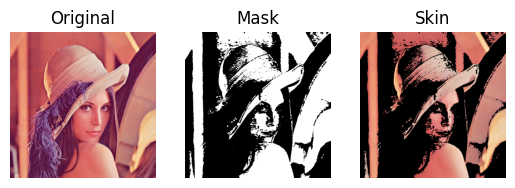

img1.jpg - Skin %: 8.19


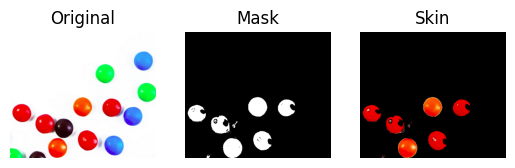

img2.jpg - Skin %: 57.94


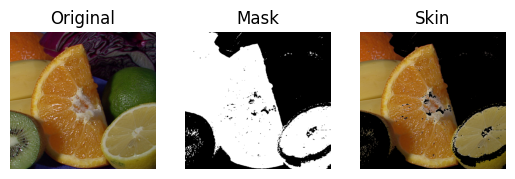

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from imageio import imread

face_dir = "FacePhoto"
mask_dir = "GroundT_FacePhoto"

# Load images
def load_images(img_dir, mask_dir):
    images, masks, names = [], [], []
    for file in os.listdir(img_dir):
        name = os.path.splitext(file)[0]
        mask_path = os.path.join(mask_dir, name + ".png")

        if os.path.exists(mask_path):
            img = imread(os.path.join(img_dir, file))
            mask = imread(mask_path)

            images.append(img)
            masks.append(mask)
            names.append(file)
    return images, masks, names

# Extract skin
def extract_skin(img, mask):
    skin = np.all(mask[:,:,:3] == [255,255,255], axis=-1)
    result = np.zeros_like(img)
    result[skin] = img[skin]
    return result, skin

# Load dataset
images, masks, names = load_images(face_dir, mask_dir)

# Process first 3 images
for i in range(min(3, len(images))):
    img, mask, name = images[i], masks[i], names[i]

    skin_img, skin_pixels = extract_skin(img, mask)

    percent = np.sum(skin_pixels) / skin_pixels.size * 100
    print(name, "- Skin %:", round(percent,2))

    # Display
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(mask); plt.title("Mask"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(skin_img); plt.title("Skin"); plt.axis('off')
    plt.show()